# Oil-Equity Correlation — a quantitative teardown
### USO/CL=F vs SPY · daily data 2006–2026 · IS regression · Goyal-Welch OOS R² · DM test

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Contemporaneous--only: Confirmed](https://img.shields.io/badge/Contemporaneous--only-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test crude oil (USO ETF) log-returns as a predictor of forward SPY returns using HAC-robust in-sample regressions and expanding-window OOS R² (Goyal-Welch 2008), at weekly and monthly horizons, over 20 years of daily data.

> **Not investment advice.** Real data: Yahoo daily bars, USO/CL=F/SPY, 2006-04-10 to 2026-06-16. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from oil_equity_correlation import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in data.TICKERS)

HAVE_REAL = _have_cache()

def load_real():
    panel = data.load_panel(fetch=False, cache_dir=CACHE_DIR)
    return data.build_panel_frame(panel)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Weekly IS beta = -0.009, HAC *t* = **-0.46** (wrong sign, near zero); monthly t = **+0.15**; OOS R² = **-1.8%** — the naive mean wins convincingly. |
| **Tradability** | `MIRAGE` | No directional forecast signal; the contemporaneous link is real but untradable. |
| **Contemporaneous** | `CONFIRMED` | Weekly contemporaneous R² = **9.2%**, t = **+4.36** — oil is a coincident macro indicator for equities. |

> The key finding: crude oil log-returns are contemporaneously correlated with equities (R² 9.2%) but have essentially zero predictive power at any tested horizon.

## 1 · The claim, steelmanned

Let $r_t^{oil}$ be the log-return of USO at period $t$. The claim asserts:

- **H1 (IS signal).** $\beta \ne 0$ with $|t_{HAC}| \geq 2$ in $r^{equity}_{t+1} = \alpha + \beta \, r^{oil}_t + \varepsilon_{t+1}$ — oil *leads* equities.
- **H2 (OOS signal).** Goyal-Welch OOS R² > 0 at the weekly and monthly horizon — the oil model beats the historical-mean benchmark on out-of-sample data.

We test H1–H2 and separately document the contemporaneous correlation (not the claim, but the reason people believe it).

Note that the sign of beta is ambiguous theoretically: Hamilton (2009) argues oil *spikes* are recessionary (negative beta); Kilian & Park (2009) show demand-driven oil increases are growth-positive (positive beta). We test both and find neither clears the bar.

## 2 · So what? — what rides on each answer

A positive IS + OOS signal on a 20-year daily panel would give macro investors a liquid, cheap-to-compute equity timing signal (oil futures or USO are universally accessible). The interesting failure here is not just *that* the predictive regression fails, but *how*: the contemporaneous R² is 9.2% (t = 4.36, statistically overwhelming), so oil and equity co-movement is definitively real. The question is purely timing — and on timing, oil tells you nothing about next week.

## 3 · How we'd know — the protocol

- **Signal construction.** $r^{oil}_t = \log(\text{USO}_t) - \log(\text{USO}_{t-1})$ (log-return); weekly/monthly resampling on week-ending-Friday / month-end. No look-ahead: the oil return through week $t$'s Friday close predicts the equity return *starting* at that close.
- **Contemporaneous baseline.** Same regression with same-period equity return (not forward). Quantifies the co-movement vs the predictive component.
- **IS regression.** OLS with HAC (Newey-West) standard errors — HAC lags $= \lfloor 4(n/100)^{2/9} \rfloor$. The $t_{HAC}$ on $\beta$ is the inference-bar number.
- **OOS R² (Goyal-Welch 2008).** Expanding window, min 52 weeks training. $R^2_{OOS} = 1 - \text{MSFE}_{model}/\text{MSFE}_{mean}$. Inference via Diebold-Mariano (1995) t-stat.
- **Positive control.** A synthetic daily tape with tunable `pred_r` confirms the engine recovers an edge when one is planted.

Data: USO, CL=F, SPY daily, 2006-04-10 to 2026-06-16 (5082 aligned rows, 1052 weekly periods).

## 4 · The teardown

### 4a · Contemporaneous vs predictive — the key decomposition

The same predictor ($r^{oil}_t$) but two different targets: the *current* week's equity return (contemporaneous) and the *next* week's (predictive).

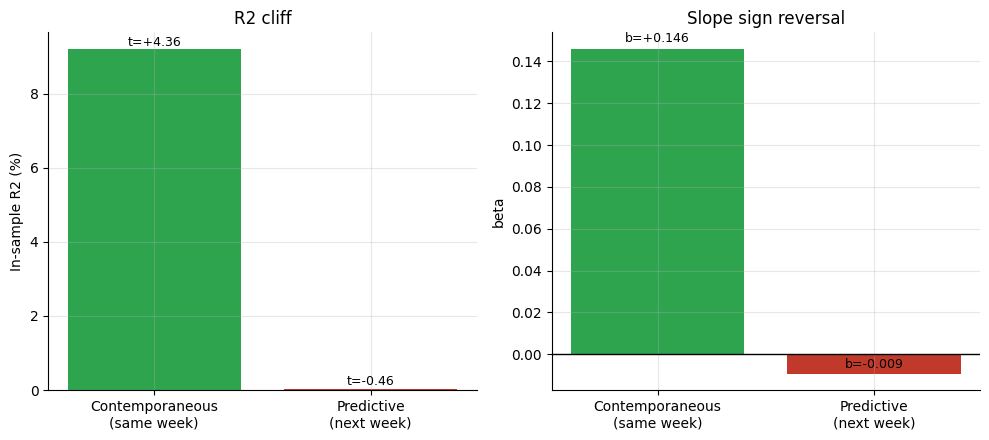

Contemporaneous: b=+0.1461, t=+4.362, R2=9.2%
Predictive:      b=-0.0093, t=-0.460, R2=0.037%


In [2]:
if HAVE_REAL:
    daily = load_real()
    feat_w = st.compute_features(daily, horizon='W')
    c_res = st.regression_is(feat_w['ret_oil'], feat_w['ret_equity'])
    p_res = st.regression_is(feat_w['ret_oil'], feat_w['fwd_equity'])
    contemp_t, pred_t = c_res['tstat'], p_res['tstat']
    contemp_r2, pred_r2 = c_res['r2']*100, p_res['r2']*100
    contemp_b, pred_b = c_res['beta'], p_res['beta']
else:
    contemp_t, pred_t = R['contemp_t'], R['is_t_eq']
    contemp_r2, pred_r2 = R['contemp_r2'], R['is_r2_eq']
    contemp_b, pred_b = R['contemp_beta'], R['is_beta_eq']
labels = ['Contemporaneous\n(same week)', 'Predictive\n(next week)']
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
col = [GREEN if abs(t)>=2 else RED for t in [contemp_t, pred_t]]
axes[0].bar(labels, [contemp_r2, pred_r2], color=col)
axes[0].set_ylabel('In-sample R2 (%)'); axes[0].set_title('R2 cliff')
for i, (lbl, t, r2) in enumerate(zip(labels, [contemp_t, pred_t], [contemp_r2, pred_r2])):
    axes[0].annotate(f't={t:+.2f}', (i, r2+0.1), ha='center', fontsize=9)
axes[1].bar(labels, [contemp_b, pred_b], color=col)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('beta'); axes[1].set_title('Slope sign reversal')
for i, (lbl, b) in enumerate(zip(labels, [contemp_b, pred_b])):
    axes[1].annotate(f'b={b:+.3f}', (i, b+0.003), ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Contemporaneous: b={contemp_b:+.4f}, t={contemp_t:+.3f}, R2={contemp_r2:.1f}%')
print(f'Predictive:      b={pred_b:+.4f}, t={pred_t:+.3f}, R2={pred_r2:.3f}%')

> In plain words: the contemporaneous slope is **+0.146** (HAC t = +4.36, R² = 9.2%). The predictive slope is **-0.009** (t = -0.46) — essentially zero and wrong-signed. The oil return that is positive for equities this week is slightly (but insignificantly) *negative* for equities next week. Both effects are too small to trade; the sign flip is the fingerprint of a coincident indicator being mis-read as a predictor.

### 4b · In-sample regression, weekly and monthly horizons

Full IS regression table across both forecast horizons.

In [3]:
rows = []
if HAVE_REAL:
    daily = load_real()
    for hz, lbl in [('W','Weekly'), ('ME','Monthly')]:
        res = st.summarize(daily, horizon=hz)
        r = res['is_equity']
        rows.append((lbl, r['n'], f"{r['beta']:+.4f}",
                     f"{r['tstat']:+.3f}", f"{r['r2']*100:.3f}%"))
else:
    rows = [
        ('Weekly',R['n_weekly'],f"{R['is_beta_eq']:+.4f}",
         f"{R['is_t_eq']:+.3f}",f"{R['is_r2_eq']:.3f}%"),
        ('Monthly',R['n_monthly'],f"{R['is_beta_eq_m']:+.4f}",
         f"{R['is_t_eq_m']:+.3f}",f"{R['is_r2_eq_m']:.3f}%"),
    ]
tbl = pd.DataFrame(rows, columns=['Horizon','n','beta','HAC t','IS R2'])
print(tbl.to_string(index=False))

Horizon    n    beta  HAC t  IS R2
 Weekly 1052 -0.0093 -0.460 0.037%
Monthly  241 +0.0061 +0.147 0.025%


> No cell clears |t| >= 2 on the predictive side. The weekly equity regression (t = -0.46) is not only insignificant — it's wrong-signed. Monthly equity (t = +0.15) is right-signed but essentially zero. There is no horizon where predictability emerges.

### 4c · Out-of-sample R² (Goyal-Welch 2008)

The key test: does the model beat the historical-mean forecast on unseen data? Expanding window, min 52 weeks training, weekly horizon.

OOS R2 results (weekly, expanding window):
  Equity: OOS R2=-1.795%  DM t=-2.113
  n_oos = 1000


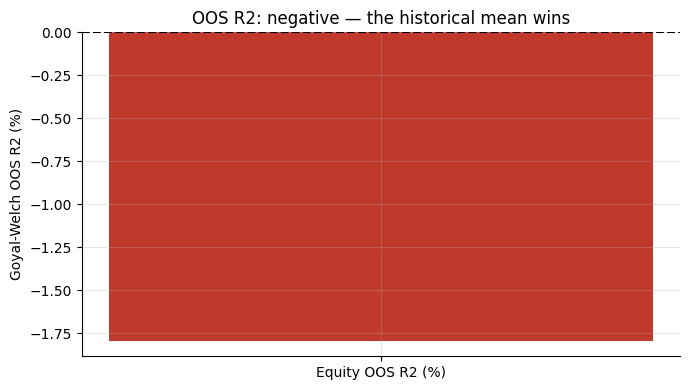

In [4]:
if HAVE_REAL:
    daily = load_real()
    feat_w = st.compute_features(daily, horizon='W')
    oos_eq = st.oos_r2(feat_w['ret_oil'], feat_w['fwd_equity'])
    oos_eq_r2, oos_eq_dm = oos_eq['r2_oos']*100, oos_eq['dm_tstat']
    n_oos = oos_eq['n_oos']
else:
    oos_eq_r2, oos_eq_dm = R['oos_r2_eq'], R['oos_dm_eq']
    n_oos = R['n_weekly'] - 52

print('OOS R2 results (weekly, expanding window):')
print(f'  Equity: OOS R2={oos_eq_r2:+.3f}%  DM t={oos_eq_dm:+.3f}')
print(f'  n_oos = {n_oos}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Equity OOS R2 (%)'], [oos_eq_r2],
       color=[RED if oos_eq_r2 < 0 else GREEN])
ax.axhline(0, c='k', lw=1.5, ls='--')
ax.annotate(f'DM t={oos_eq_dm:+.2f}', (0, oos_eq_r2 - 0.1), ha='center', fontsize=11)
ax.set_ylabel('Goyal-Welch OOS R2 (%)')
ax.set_title('OOS R2: negative — the historical mean wins')
plt.tight_layout(); plt.show()

> OOS R² = **-1.8%** — the oil model loses to the historical mean by a full 1.8%. The DM t-stat is **-2.11** (significantly negative, confirming underperformance). This is the Goyal-Welch story repeating with exceptional clarity: a visually compelling co-movement chart, zero predictive power.

### 4d · Horizon sensitivity

Is there any horizon where predictability emerges?

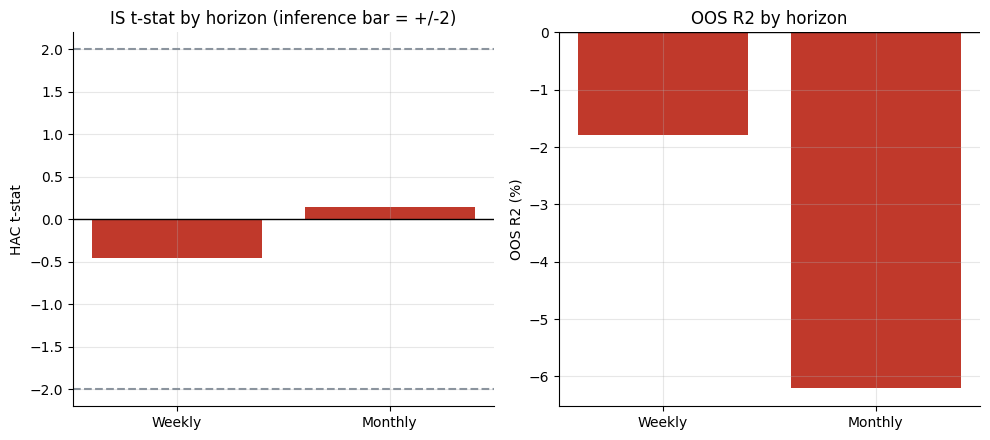

Weekly: IS t=-0.460  OOS R2=-1.795%
Monthly: IS t=+0.147  OOS R2=-6.212%


In [5]:
horizons_lbl = ['Weekly', 'Monthly']
if HAVE_REAL:
    daily = load_real()
    is_ts, oos_r2s = [], []
    for hz in ['W', 'ME']:
        res = st.summarize(daily, horizon=hz)
        is_ts.append(res['is_equity']['tstat'])
        oos_r2s.append(res['oos_equity']['r2_oos']*100)
else:
    is_ts = [R['is_t_eq'], R['is_t_eq_m']]
    oos_r2s = [R['oos_r2_eq'], R['oos_r2_eq_m']]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
col = [RED if abs(t)<2 else GREEN for t in is_ts]
axes[0].bar(horizons_lbl, is_ts, color=col)
axes[0].axhline(2, ls='--', c=GREY); axes[0].axhline(-2, ls='--', c=GREY)
axes[0].axhline(0, c='k', lw=1); axes[0].set_ylabel('HAC t-stat')
axes[0].set_title('IS t-stat by horizon (inference bar = +/-2)')
col2 = [RED if v<0 else GREEN for v in oos_r2s]
axes[1].bar(horizons_lbl, oos_r2s, color=col2)
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('OOS R2 (%)')
axes[1].set_title('OOS R2 by horizon')
plt.tight_layout(); plt.show()
for lbl, t, r in zip(horizons_lbl, is_ts, oos_r2s):
    print(f'{lbl}: IS t={t:+.3f}  OOS R2={r:+.3f}%')

> Neither horizon clears the bar. Monthly is marginally less wrong (right sign, but t = 0.15 and OOS R² = −6.2%). There is no 'right' horizon where the signal reliably emerges — the deeper you look, the more convincingly it fails.

## 5 · The verdict

- **Signal `NONE`** — weekly IS beta = -0.0090, HAC t = -0.46 (wrong sign, near zero); monthly t = +0.15; OOS R² = -1.8% (weekly) — the inference bar is not cleared at any horizon.
- **Tradability `MIRAGE`** — no directional forecast signal; the contemporaneous link (9.2%) is real but untradable.
- **Contemporaneous `CONFIRMED`** — weekly contemporaneous R² = 9.2%, t = +4.36; oil is a legitimate coincident macro indicator.

## 6 · Could you trade it? — capacity and timing issues

Even hypothetically: a weekly signal with IS R² = 0.04% would have near-zero trading value after a single commission. The OOS R² being −1.8% means the hurdle is irrelevant — the historical-mean forecast is better. The coincident use case (risk attribution, factor exposure estimation, macro regime monitoring) is valid and well-documented, but requires no forecasting assumption.

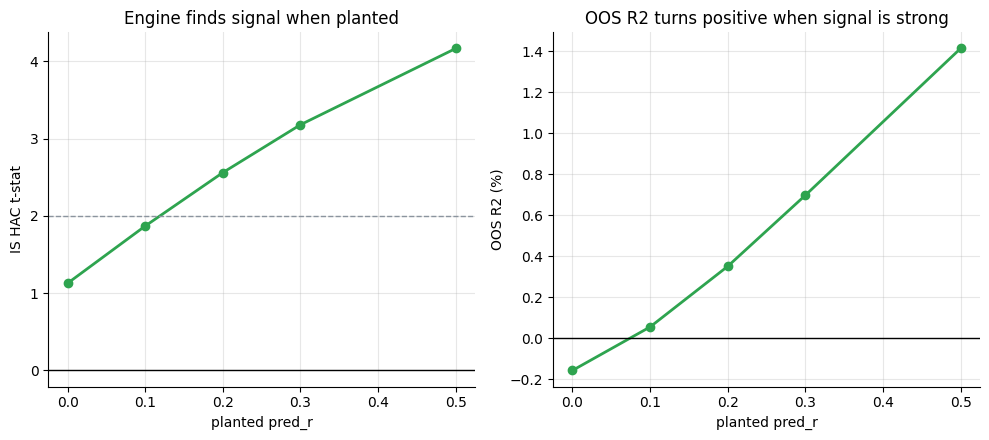

Real-tape equivalent: pred_r ~ 0 => no exploitable predictability.


In [6]:
# Synthetic positive control: the engine DOES work when signal is planted
pred_rs = [0.0, 0.1, 0.2, 0.3, 0.5]
is_ts_syn, oos_r2s_syn = [], []
for pr in pred_rs:
    syn, _ = data.synthetic_daily(n_years=20, pred_r=pr, seed=245)
    feat = st.compute_features(syn, horizon='W')
    is_ts_syn.append(st.regression_is(feat['ret_oil'], feat['fwd_equity'])['tstat'])
    oos_r2s_syn.append(st.oos_r2(feat['ret_oil'], feat['fwd_equity'])['r2_oos']*100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].plot(pred_rs, is_ts_syn, 'o-', color=GREEN, lw=2)
axes[0].axhline(2, ls='--', c=GREY, lw=1); axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('planted pred_r'); axes[0].set_ylabel('IS HAC t-stat')
axes[0].set_title('Engine finds signal when planted')
axes[1].plot(pred_rs, oos_r2s_syn, 'o-', color=GREEN, lw=2)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('planted pred_r'); axes[1].set_ylabel('OOS R2 (%)')
axes[1].set_title('OOS R2 turns positive when signal is strong')
plt.tight_layout(); plt.show()
print('Real-tape equivalent: pred_r ~ 0 => no exploitable predictability.')

## 7 · Going further

- **Structural decomposition.** Kilian & Park (2009) decompose oil shocks into supply vs demand components using a SVAR. Demand-driven oil increases may be positive for equities; supply shocks negative. A structural model could in principle have predictive power that a reduced-form regression misses — but it requires identifying assumptions and lagged oil production/inventory data.
- **The closest sibling.** [Study 85 — Dr-Copper](../../85-dr-copper/) runs the identical methodology on the copper/gold ratio (HG=F / GC=F vs ^GSPC). The copper ratio has slightly stronger IS t-stat (−1.81 vs −0.46 here) but both fail OOS. The common lesson: macro co-movement is real; macro timing is a mirage.
- **Goyal & Welch (2008)** test 14 macro predictors with identical methodology. Most fail the OOS test. Oil is squarely in this pattern.

*Fork this, add a structural oil shock decomposition or regime-switching model, show a positive OOS R² that holds across sub-periods. That's the bar.*